<a href="https://colab.research.google.com/github/Lian067/Lian067/blob/main/Classification/4_haralick_texture/Haralick_Texture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Image Classfication using Texture**

In [1]:
!git clone https://github.com/deepanrajm/machine_learning.git

Cloning into 'machine_learning'...
remote: Enumerating objects: 73108, done.
remote: Counting objects: 100% (3078/3078), done.
remote: Compressing objects: 100% (2880/2880), done.
remote: Total 73108 (delta 219), reused 3033 (delta 191), pack-reused 70030 (from 1)
Receiving objects: 100% (73108/73108), 127.93 MiB | 26.27 MiB/s, done.
Resolving deltas: 100% (221/221), done.
Updating files: 100% (5870/5870), done.


In [2]:
!pip install mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 44.4 MB/s eta 0:00:00


In [3]:
from sklearn.svm import LinearSVC
import argparse
import mahotas
import glob
import cv2
from sklearn.linear_model import LogisticRegression
from google.colab.patches import cv2_imshow

In [4]:
data = []
labels = []

**HARALICK TEXTURE**

![alt text](https://drive.google.com/uc?id=1wW6kZ9ESBY7hminUlHnlsNDLUol2Fqqk)

In [5]:
for imagePath in glob.glob("/content/machine_learning/Classification/4_haralick_texture/training" + "/*.png"):
	# load the image, convert it to grayscale, and extract the texture
	# name from the filename
	image = cv2.imread(imagePath)
	image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
	texture = imagePath[imagePath.rfind("/") + 1:].split("_")[0]

	# extract Haralick texture features in 4 directions, then take the
	# mean of each direction
	features = mahotas.features.haralick(image).mean(axis=0)

	# update the data and labels
	data.append(features)
	labels.append(texture)

In [6]:
print("[INFO] training model...")
model = LogisticRegression()
model.fit(data, labels)
print("[INFO] classifying...")

[INFO] training model...
[INFO] classifying...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


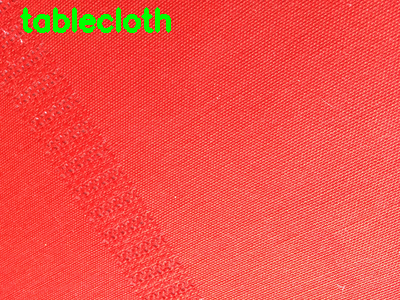

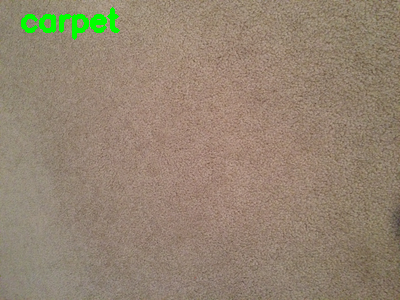

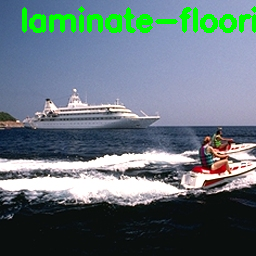

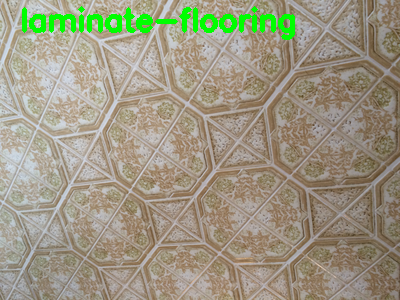

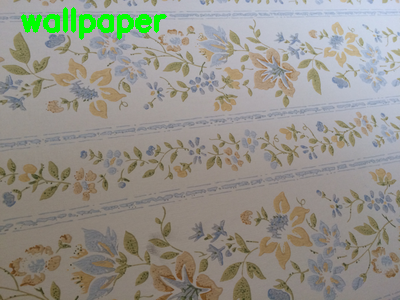

In [7]:
for imagePath in glob.glob("/content/machine_learning/Classification/4_haralick_texture/testing"+ "/*.png"):
	# load the image, convert it to grayscale, and extract Haralick
	# texture from the test image
	image = cv2.imread(imagePath)
	gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
	features = mahotas.features.haralick(gray).mean(axis=0)

	# classify the test image
	pred = model.predict(features.reshape(1, -1))[0]
	cv2.putText(image, pred, (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 1.0,
		(0, 255, 0), 3)

	# show the output image
	cv2_imshow(image)